# 03 — Exploratory Data Analysis (EDA)

## Objective
Understand the patterns, distributions, and relationships in the
cleaned Bangalore ride sharing data — with a specific focus on
what drives surge pricing.

## Business Questions We Answer
1. What does the distribution of surge multiplier look like?
2. Which hours of the day have highest surge?
3. How does surge vary across days of the week?
4. Does weather significantly impact surge?
5. Which pickup zones have highest average surge?
6. How does surge behave during holidays vs normal days?
7. How does surge vary month by month across 2025?
8. What is the relationship between distance and fare?
9. What is the ride volume pattern through the day?
10. Which vehicle types are most in demand?

## Data Used
Cleaned tables from data/processed/

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 50)
pd.set_option("display.float_format", lambda x: f"{x:.2f}")

# Plot style
plt.rcParams["figure.dpi"]        = 130
plt.rcParams["axes.spines.top"]   = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.titlesize"]    = 13
plt.rcParams["axes.titleweight"]  = "bold"

print("Libraries loaded ✅")

c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\computation\expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.8.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
c:\Users\dsp96\anaconda3\lib\site-packages\pandas\core\arrays\masked.py:61: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (


Libraries loaded ✅


In [2]:
PATH = "../data/processed/"

rides_df   = pd.read_csv(PATH + "rides_clean.csv",   parse_dates=["ride_timestamp"])
drivers_df = pd.read_csv(PATH + "drivers_clean.csv", parse_dates=["joined_date"])
users_df   = pd.read_csv(PATH + "users_clean.csv",   parse_dates=["signup_date"])
payments_df= pd.read_csv(PATH + "payments_clean.csv")
weather_df = pd.read_csv(PATH + "weather_clean.csv", parse_dates=["timestamp"])

print("Cleaned data loaded ✅")
print(f"  rides    : {rides_df.shape}")
print(f"  drivers  : {drivers_df.shape}")
print(f"  users    : {users_df.shape}")
print(f"  payments : {payments_df.shape}")
print(f"  weather  : {weather_df.shape}")

Cleaned data loaded ✅
  rides    : (50000, 25)
  drivers  : (3000, 16)
  users    : (20000, 13)
  payments : (39191, 8)
  weather  : (87600, 7)


## Section 1 — Target Variable Analysis
### Question: What does the surge multiplier distribution look like?
Before analyzing what causes surge, we need to deeply understand
the target variable itself.

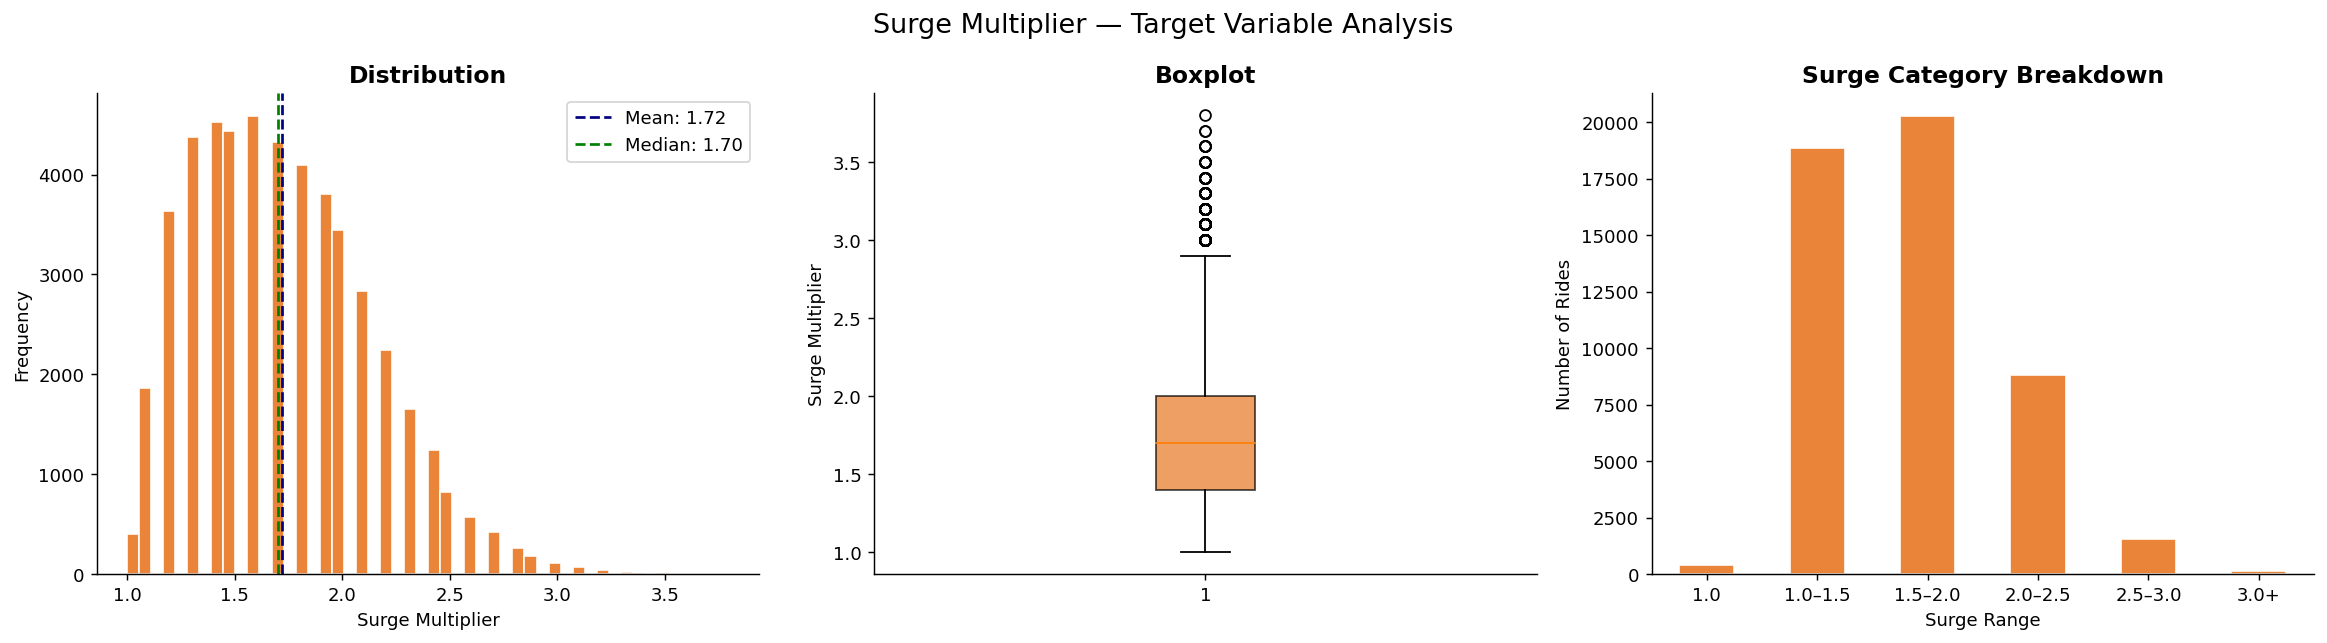

Surge Multiplier Statistics:
count   50000.00
mean        1.72
std         0.41
min         1.00
25%         1.40
50%         1.70
75%         2.00
max         3.80
Name: surge_multiplier, dtype: float64


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Surge Multiplier — Target Variable Analysis", fontsize=15)

surge = rides_df["surge_multiplier"].dropna()

# Histogram
axes[0].hist(surge, bins=50, color="#E87722", edgecolor="white", alpha=0.9)
axes[0].axvline(surge.mean(),   color="navy",  linestyle="--", label=f"Mean: {surge.mean():.2f}")
axes[0].axvline(surge.median(), color="green", linestyle="--", label=f"Median: {surge.median():.2f}")
axes[0].set_title("Distribution")
axes[0].set_xlabel("Surge Multiplier")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Boxplot
axes[1].boxplot(surge, patch_artist=True,
                boxprops=dict(facecolor="#E87722", alpha=0.7))
axes[1].set_title("Boxplot")
axes[1].set_ylabel("Surge Multiplier")

# Surge category breakdown
bins   = [0.9, 1.0, 1.5, 2.0, 2.5, 3.0, 5.0]
labels = ["1.0", "1.0–1.5", "1.5–2.0", "2.0–2.5", "2.5–3.0", "3.0+"]
surge_cat = pd.cut(surge, bins=bins, labels=labels)
surge_cat.value_counts().sort_index().plot(
    kind="bar", ax=axes[2], color="#E87722", edgecolor="white", alpha=0.9
)
axes[2].set_title("Surge Category Breakdown")
axes[2].set_xlabel("Surge Range")
axes[2].set_ylabel("Number of Rides")
axes[2].tick_params(axis="x", rotation=0)

plt.tight_layout()
plt.savefig("../data/processed/eda_01_surge_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

print("Surge Multiplier Statistics:")
print(surge.describe().round(3))

### Observation
Write your observation here after running the cell. Example:

- The surge distribution is right-skewed — majority of rides
  are between 1.0 and 2.0x surge
- The mean surge is around X.XX which means on average rides
  cost X times the base fare
- High surge rides (above 3.0) are rare but exist — these
  likely correspond to rain events or late night holiday rides

## Section 2 — Time-Based Patterns
### Question: Which hours and days have the highest surge?
Time is one of the most powerful signals in surge prediction.

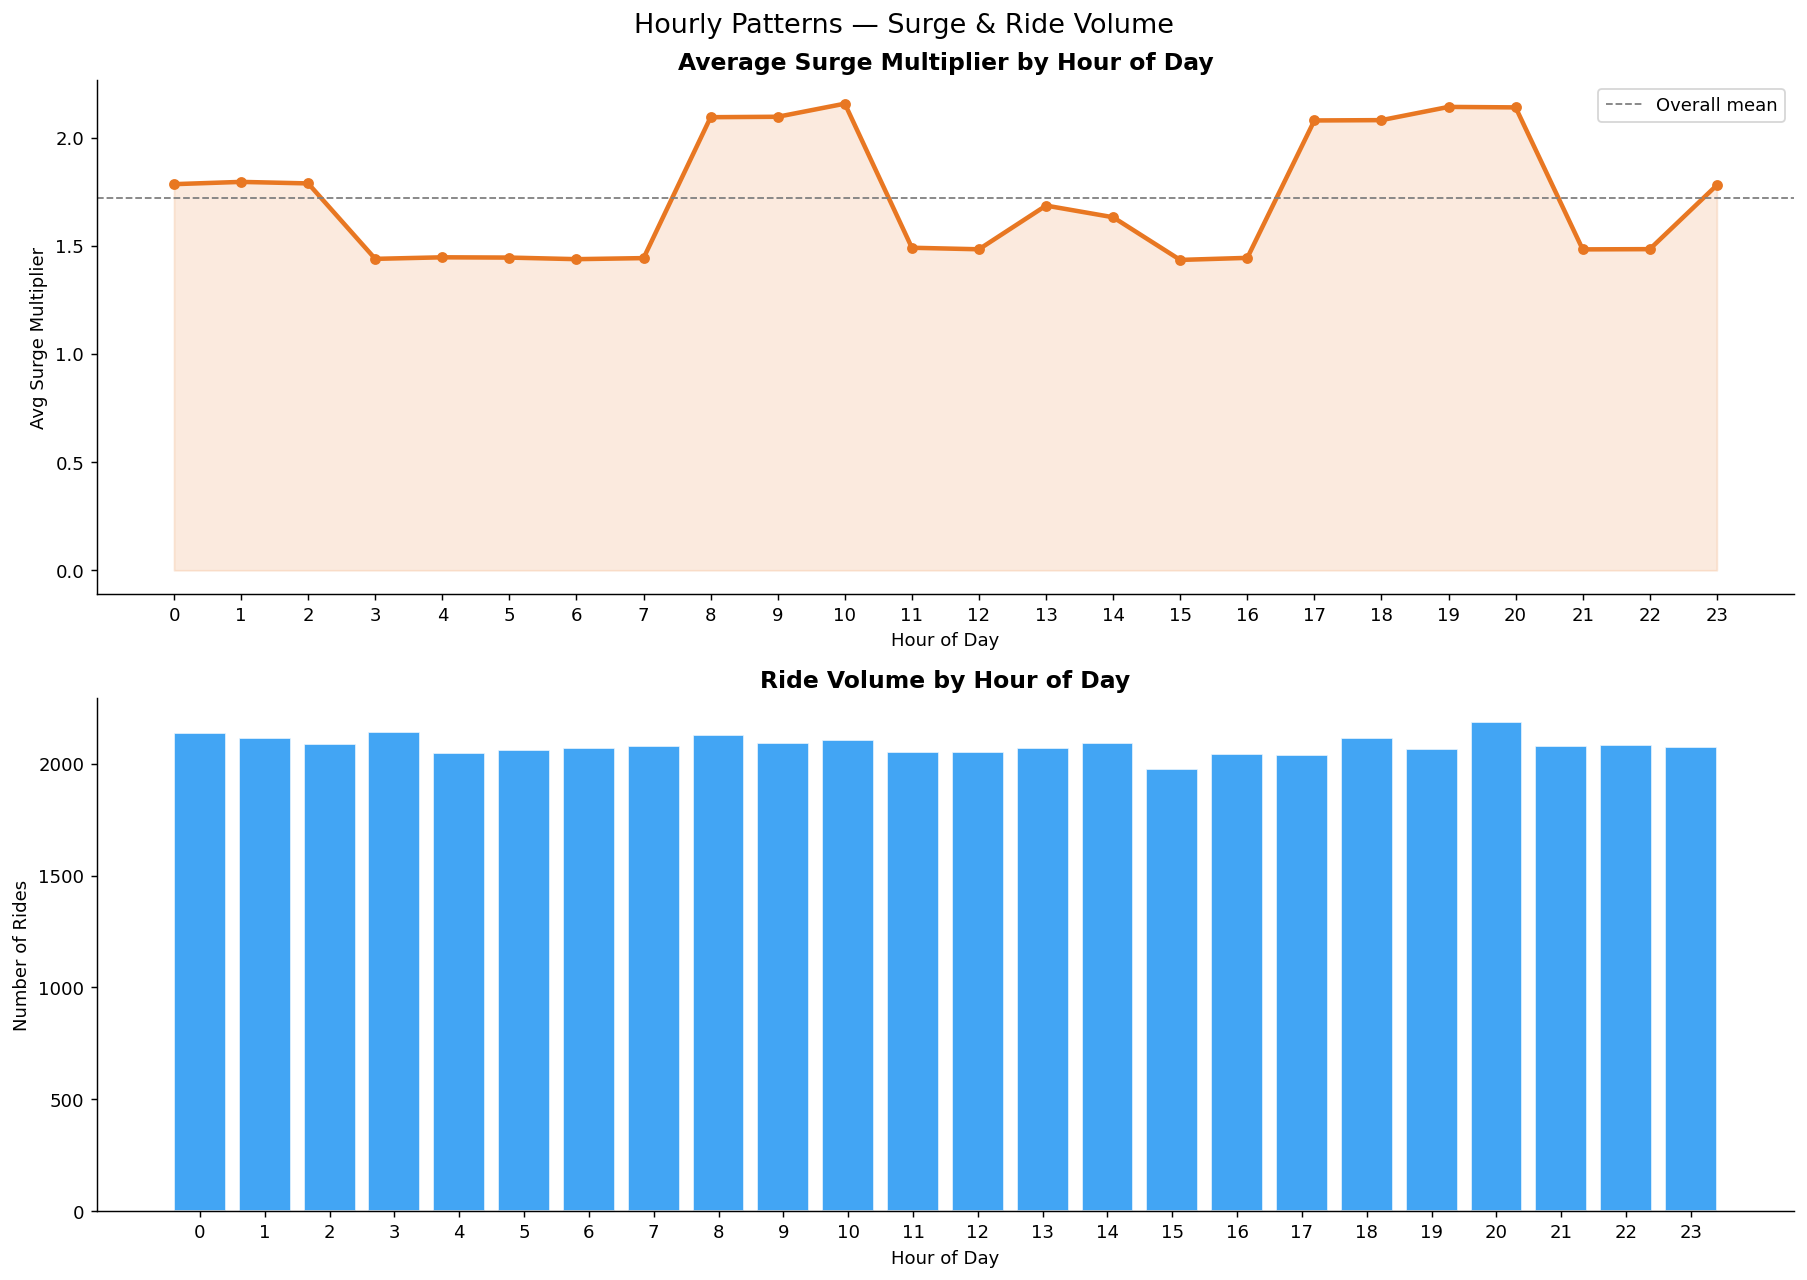

Top 5 highest surge hours:
    hour  surge_multiplier
10    10              2.16
19    19              2.14
20    20              2.14
9      9              2.10
8      8              2.09


In [4]:
hourly_surge = rides_df.groupby("hour")["surge_multiplier"].mean().reset_index()
hourly_volume = rides_df.groupby("hour").size().reset_index(name="ride_count")

fig, axes = plt.subplots(2, 1, figsize=(14, 10))
fig.suptitle("Hourly Patterns — Surge & Ride Volume", fontsize=15)

# Average surge by hour
axes[0].plot(hourly_surge["hour"], hourly_surge["surge_multiplier"],
             color="#E87722", linewidth=2.5, marker="o", markersize=5)
axes[0].fill_between(hourly_surge["hour"], hourly_surge["surge_multiplier"],
                     alpha=0.15, color="#E87722")
axes[0].axhline(y=rides_df["surge_multiplier"].mean(),
                color="gray", linestyle="--", linewidth=1, label="Overall mean")
axes[0].set_title("Average Surge Multiplier by Hour of Day")
axes[0].set_xlabel("Hour of Day")
axes[0].set_ylabel("Avg Surge Multiplier")
axes[0].set_xticks(range(0, 24))
axes[0].legend()

# Ride volume by hour
axes[1].bar(hourly_volume["hour"], hourly_volume["ride_count"],
            color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_title("Ride Volume by Hour of Day")
axes[1].set_xlabel("Hour of Day")
axes[1].set_ylabel("Number of Rides")
axes[1].set_xticks(range(0, 24))

plt.tight_layout()
plt.savefig("../data/processed/eda_02_hourly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 highest surge hours:")
print(hourly_surge.sort_values("surge_multiplier", ascending=False).head())

### Observation
- Clear double peak visible — morning rush (8–10am) and
  evening rush (5–8pm) — matching Bangalore IT office hours
- Late night (11pm–2am) also shows elevated surge — pub/restaurant crowd
- Lowest surge is in the early morning hours (3–6am) when
  demand is minimal
- Ride volume peaks mirror surge peaks — demand and surge move together

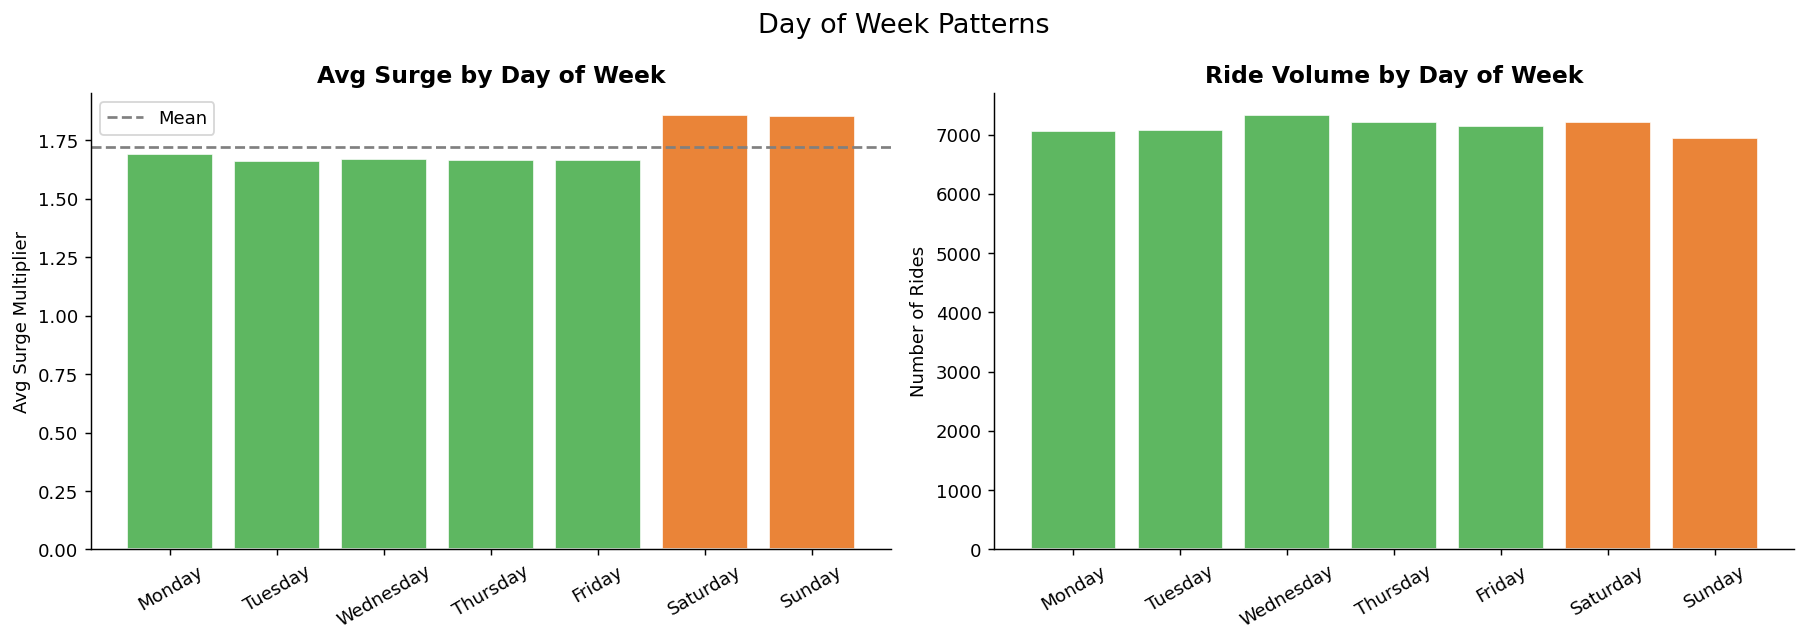

In [5]:
day_order = ["Monday", "Tuesday", "Wednesday", "Thursday",
             "Friday", "Saturday", "Sunday"]

day_surge  = rides_df.groupby("day_of_week")["surge_multiplier"].mean().reindex(day_order)
day_volume = rides_df.groupby("day_of_week").size().reindex(day_order)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Day of Week Patterns", fontsize=15)

colors = ["#4CAF50" if d not in ["Saturday","Sunday"] else "#E87722" for d in day_order]

axes[0].bar(day_order, day_surge.values, color=colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Avg Surge by Day of Week")
axes[0].set_ylabel("Avg Surge Multiplier")
axes[0].tick_params(axis="x", rotation=30)
axes[0].axhline(day_surge.mean(), color="gray", linestyle="--", label="Mean")
axes[0].legend()

axes[1].bar(day_order, day_volume.values, color=colors, edgecolor="white", alpha=0.9)
axes[1].set_title("Ride Volume by Day of Week")
axes[1].set_ylabel("Number of Rides")
axes[1].tick_params(axis="x", rotation=30)

plt.tight_layout()
plt.savefig("../data/processed/eda_03_day_of_week.png", dpi=150, bbox_inches="tight")
plt.show()

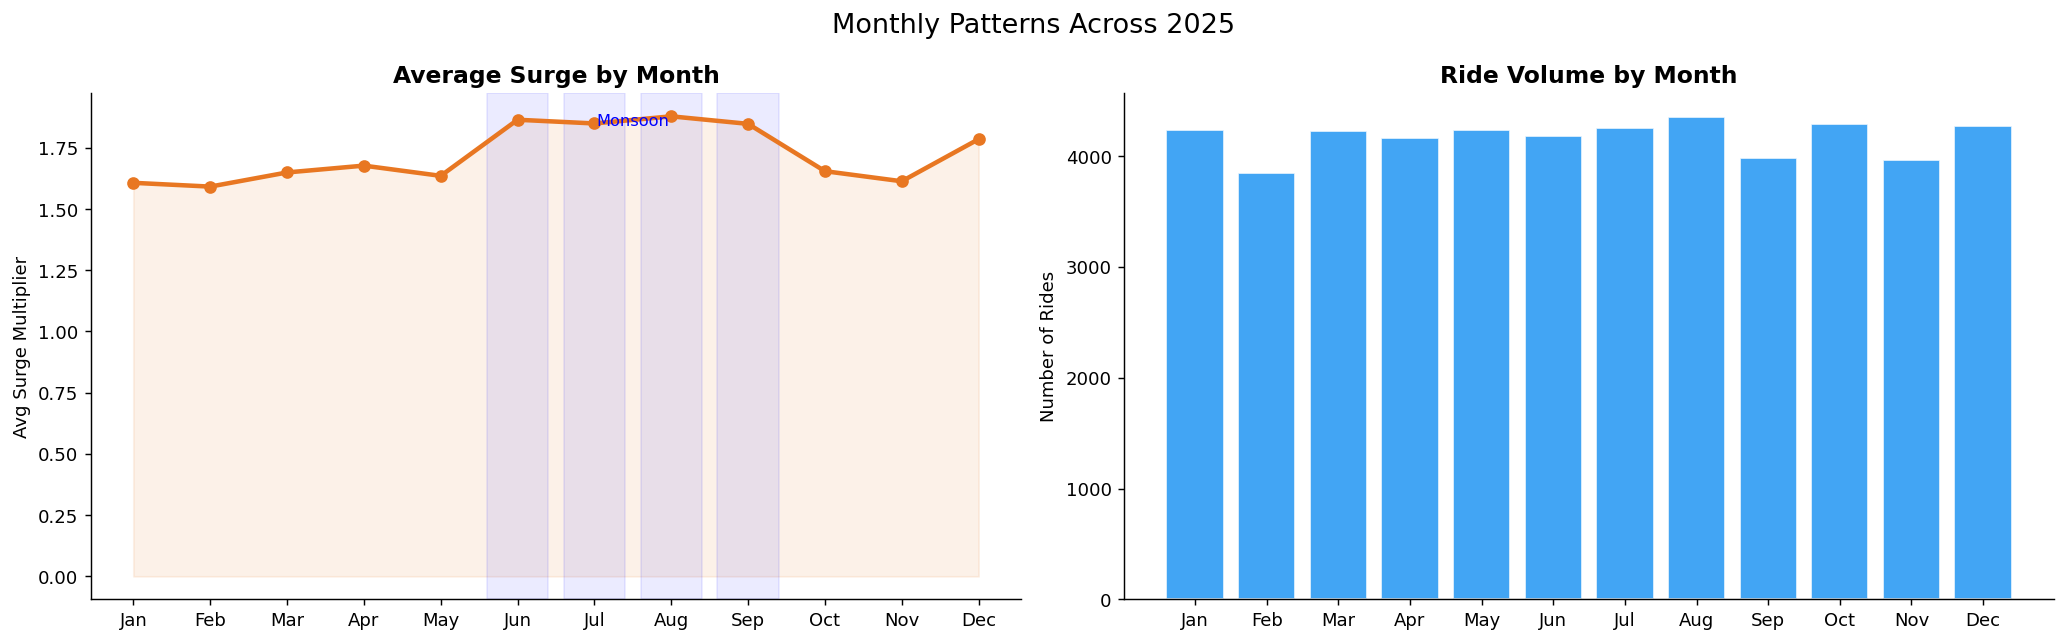

In [6]:
month_labels = ["Jan","Feb","Mar","Apr","May","Jun",
                "Jul","Aug","Sep","Oct","Nov","Dec"]

monthly = rides_df.groupby("month").agg(
    avg_surge  = ("surge_multiplier", "mean"),
    ride_count = ("ride_id", "count")
).reset_index()

monthly["month_name"] = monthly["month"].apply(lambda x: month_labels[x-1])

fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle("Monthly Patterns Across 2025", fontsize=15)

# Surge line
axes[0].plot(monthly["month"], monthly["avg_surge"],
             color="#E87722", linewidth=2.5, marker="o", markersize=6)
axes[0].fill_between(monthly["month"], monthly["avg_surge"],
                     alpha=0.1, color="#E87722")
axes[0].set_xticks(monthly["month"])
axes[0].set_xticklabels(monthly["month_name"])
axes[0].set_title("Average Surge by Month")
axes[0].set_ylabel("Avg Surge Multiplier")

# Shade monsoon months
for m in [6, 7, 8, 9]:
    axes[0].axvspan(m - 0.4, m + 0.4, alpha=0.08, color="blue")
axes[0].text(7.5, monthly["avg_surge"].max() * 0.98,
             "Monsoon", color="blue", fontsize=9, ha="center")

# Volume bars
axes[1].bar(monthly["month"], monthly["ride_count"],
            color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_xticks(monthly["month"])
axes[1].set_xticklabels(monthly["month_name"])
axes[1].set_title("Ride Volume by Month")
axes[1].set_ylabel("Number of Rides")

plt.tight_layout()
plt.savefig("../data/processed/eda_04_monthly_patterns.png", dpi=150, bbox_inches="tight")
plt.show()

## Section 3 — Weather Impact
### Question: Does weather actually move the surge needle significantly?
This is critical — if weather has weak impact, it is not
a useful feature. If it has strong impact, it must be in the model.

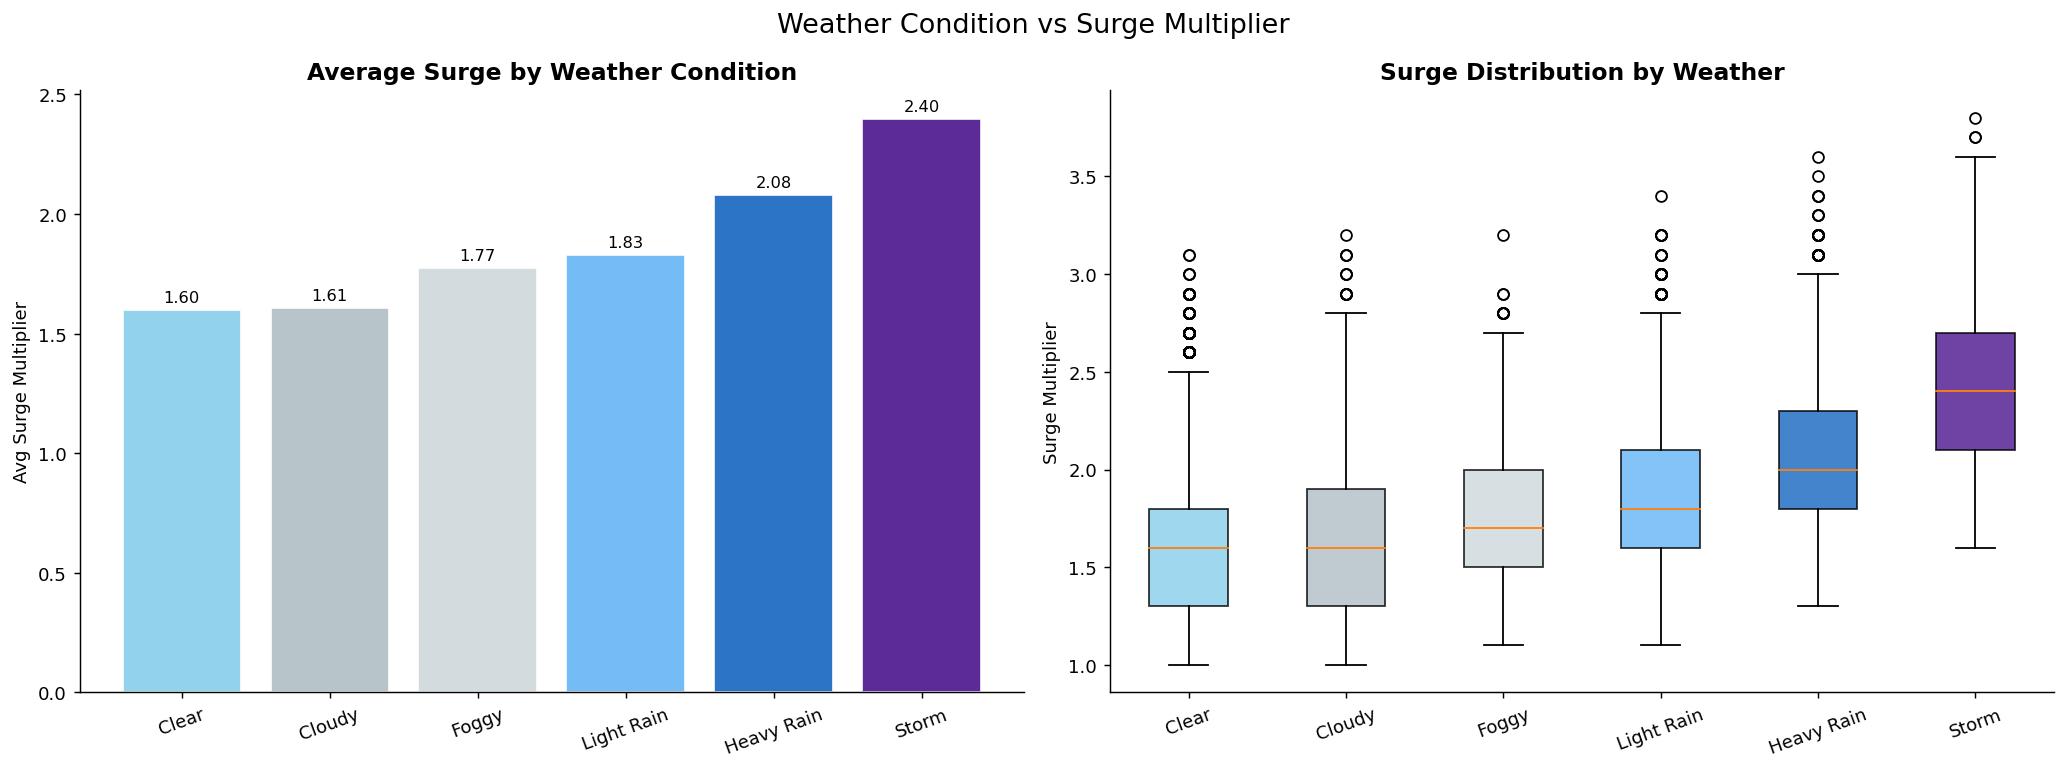

Weather vs Surge Summary:
weather_condition  avg_surge  median_surge  ride_count
            Clear       1.60          1.60       19782
           Cloudy       1.61          1.60       12966
            Foggy       1.77          1.70        2726
       Light Rain       1.83          1.80        7889
       Heavy Rain       2.08          2.00        4806
            Storm       2.40          2.40        1831


In [7]:
weather_order = ["Clear", "Cloudy", "Foggy", "Light Rain", "Heavy Rain", "Storm"]

weather_surge = rides_df.groupby("weather_condition").agg(
    avg_surge  = ("surge_multiplier", "mean"),
    median_surge = ("surge_multiplier", "median"),
    ride_count = ("ride_id", "count")
).reindex(weather_order).reset_index()

weather_colors = ["#87CEEB", "#B0BEC5", "#CFD8DC", "#64B5F6", "#1565C0", "#4A148C"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))
fig.suptitle("Weather Condition vs Surge Multiplier", fontsize=15)

# Bar chart — avg surge by weather
bars = axes[0].bar(weather_surge["weather_condition"],
                   weather_surge["avg_surge"],
                   color=weather_colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Average Surge by Weather Condition")
axes[0].set_ylabel("Avg Surge Multiplier")
axes[0].tick_params(axis="x", rotation=20)

for bar, val in zip(bars, weather_surge["avg_surge"]):
    axes[0].text(bar.get_x() + bar.get_width()/2,
                 bar.get_height() + 0.02,
                 f"{val:.2f}", ha="center", va="bottom", fontsize=9)

# Boxplot — surge distribution per weather
weather_data = [
    rides_df[rides_df["weather_condition"] == w]["surge_multiplier"].dropna().values
    for w in weather_order
]
bp = axes[1].boxplot(weather_data, patch_artist=True, labels=weather_order)
for patch, color in zip(bp["boxes"], weather_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
axes[1].set_title("Surge Distribution by Weather")
axes[1].set_ylabel("Surge Multiplier")
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.savefig("../data/processed/eda_05_weather_surge.png", dpi=150, bbox_inches="tight")
plt.show()

print("Weather vs Surge Summary:")
print(weather_surge[["weather_condition","avg_surge","median_surge","ride_count"]].to_string(index=False))

## Section 4 — Zone Analysis
### Question: Which Bangalore zones consistently have highest surge?
This tells us whether location is a strong feature for the model.

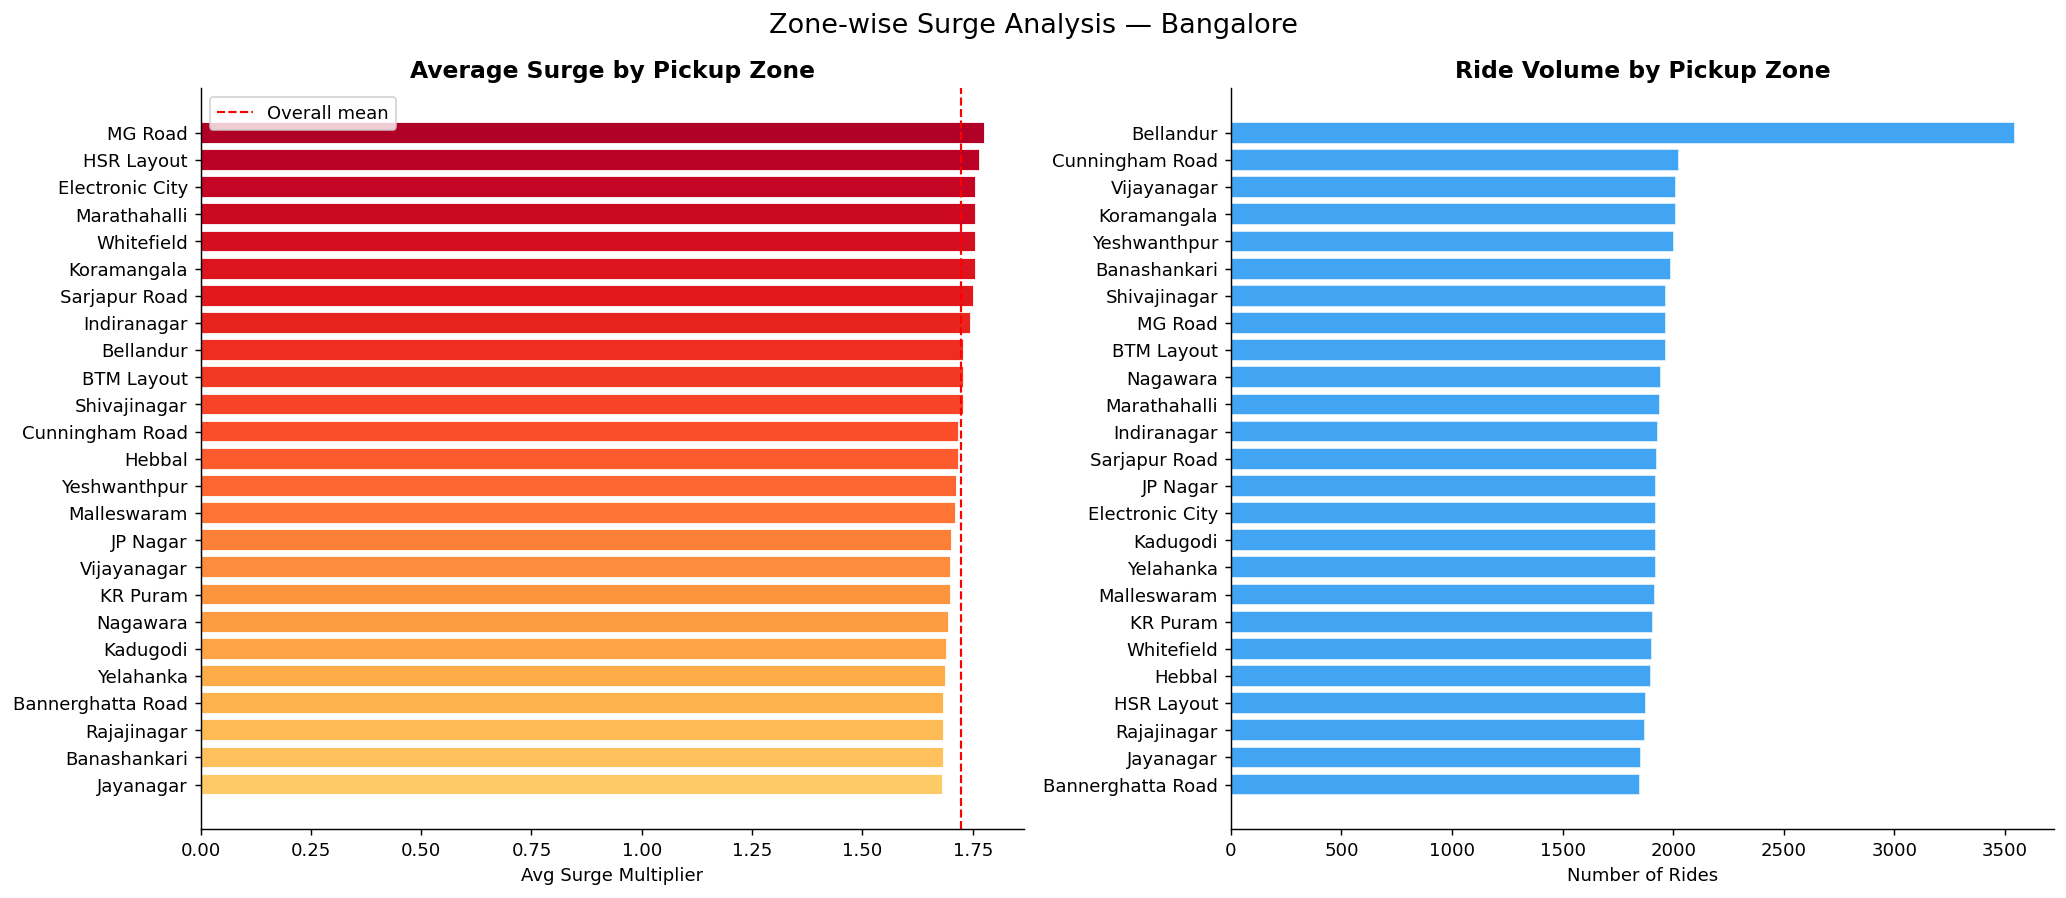

Top 5 highest surge zones:
    pickup_zone  avg_surge  ride_count
        MG Road       1.78        1966
     HSR Layout       1.77        1876
Electronic City       1.76        1923
   Marathahalli       1.76        1941
     Whitefield       1.76        1905

Bottom 5 lowest surge zones:
      pickup_zone  avg_surge  ride_count
        Yelahanka       1.69        1920
Bannerghatta Road       1.68        1852
      Rajajinagar       1.68        1872
     Banashankari       1.68        1992
        Jayanagar       1.68        1853


In [8]:
zone_surge = rides_df.groupby("pickup_zone").agg(
    avg_surge  = ("surge_multiplier", "mean"),
    ride_count = ("ride_id", "count"),
    median_surge = ("surge_multiplier", "median")
).reset_index().sort_values("avg_surge", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle("Zone-wise Surge Analysis — Bangalore", fontsize=15)

# Horizontal bar chart sorted by avg surge
colors = plt.cm.YlOrRd(
    np.linspace(0.3, 0.9, len(zone_surge))
)[::-1]

axes[0].barh(zone_surge["pickup_zone"], zone_surge["avg_surge"],
             color=colors, edgecolor="white")
axes[0].set_title("Average Surge by Pickup Zone")
axes[0].set_xlabel("Avg Surge Multiplier")
axes[0].axvline(rides_df["surge_multiplier"].mean(),
                color="red", linestyle="--", linewidth=1.2, label="Overall mean")
axes[0].legend()
axes[0].invert_yaxis()

# Ride volume by zone
zone_vol = rides_df.groupby("pickup_zone").size().reset_index(name="count")
zone_vol = zone_vol.sort_values("count", ascending=False)
axes[1].barh(zone_vol["pickup_zone"], zone_vol["count"],
             color="#2196F3", edgecolor="white", alpha=0.85)
axes[1].set_title("Ride Volume by Pickup Zone")
axes[1].set_xlabel("Number of Rides")
axes[1].invert_yaxis()

plt.tight_layout()
plt.savefig("../data/processed/eda_06_zone_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print("Top 5 highest surge zones:")
print(zone_surge[["pickup_zone","avg_surge","ride_count"]].head().to_string(index=False))
print("\nBottom 5 lowest surge zones:")
print(zone_surge[["pickup_zone","avg_surge","ride_count"]].tail().to_string(index=False))

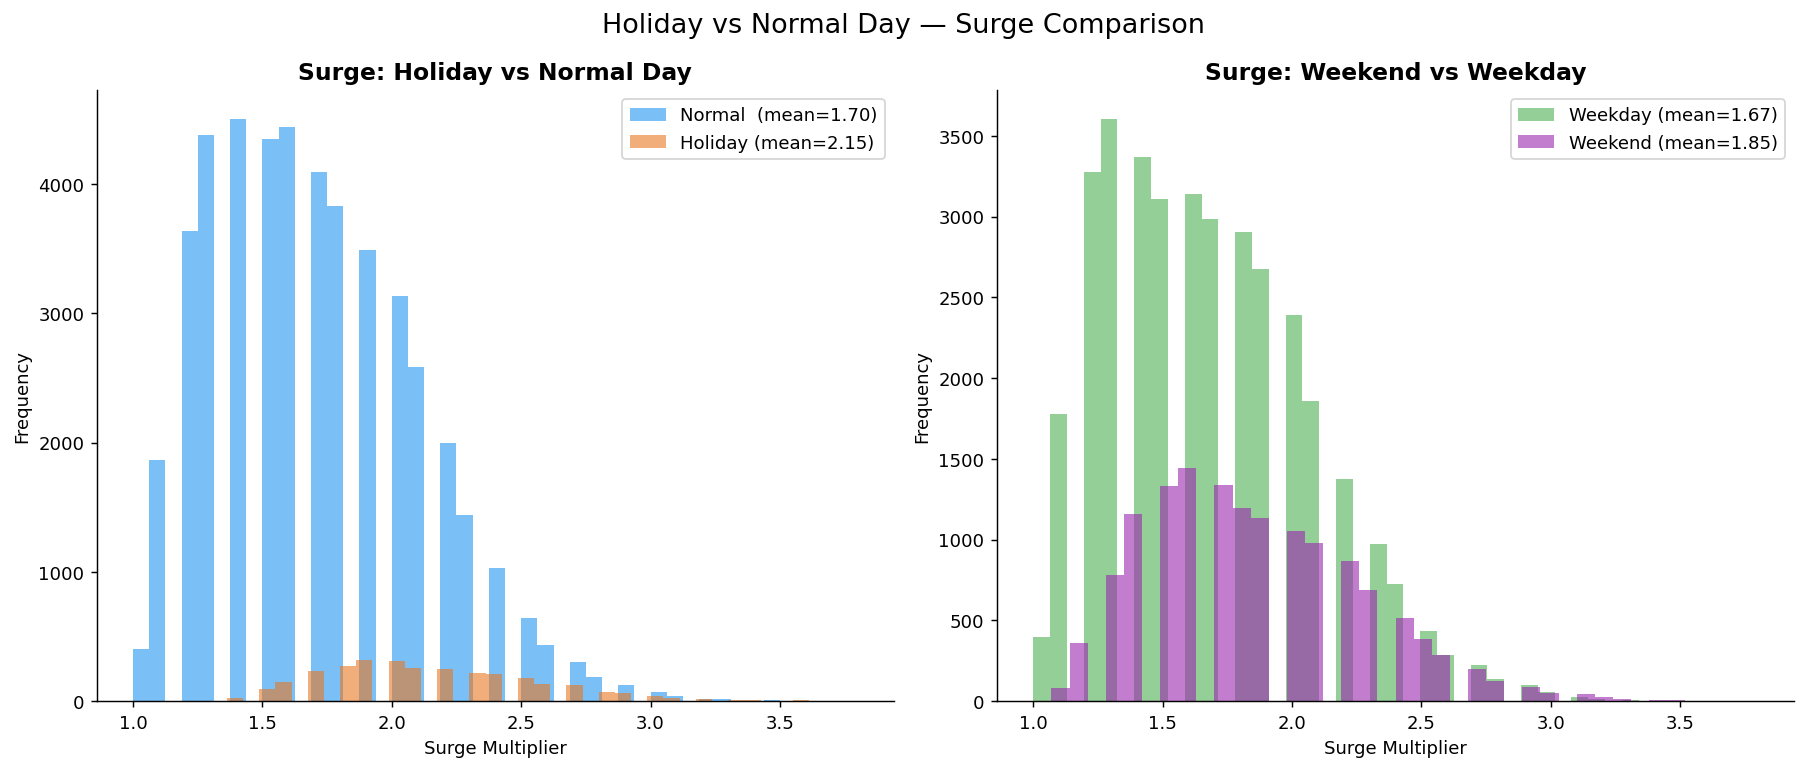

Holiday avg surge  : 2.147
Normal  avg surge  : 1.695
Difference         : 0.452

Weekend avg surge  : 1.855
Weekday avg surge  : 1.670


In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle("Holiday vs Normal Day — Surge Comparison", fontsize=15)

holiday_surge  = rides_df[rides_df["is_holiday"] == True]["surge_multiplier"]
normal_surge   = rides_df[rides_df["is_holiday"] == False]["surge_multiplier"]
weekend_surge  = rides_df[rides_df["is_weekend"] == True]["surge_multiplier"]
weekday_surge  = rides_df[rides_df["is_weekend"] == False]["surge_multiplier"]

# Holiday comparison
axes[0].hist(normal_surge,  bins=40, alpha=0.6, color="#2196F3", label=f"Normal  (mean={normal_surge.mean():.2f})")
axes[0].hist(holiday_surge, bins=40, alpha=0.6, color="#E87722", label=f"Holiday (mean={holiday_surge.mean():.2f})")
axes[0].set_title("Surge: Holiday vs Normal Day")
axes[0].set_xlabel("Surge Multiplier")
axes[0].set_ylabel("Frequency")
axes[0].legend()

# Weekend comparison
axes[1].hist(weekday_surge, bins=40, alpha=0.6, color="#4CAF50", label=f"Weekday (mean={weekday_surge.mean():.2f})")
axes[1].hist(weekend_surge, bins=40, alpha=0.6, color="#9C27B0", label=f"Weekend (mean={weekend_surge.mean():.2f})")
axes[1].set_title("Surge: Weekend vs Weekday")
axes[1].set_xlabel("Surge Multiplier")
axes[1].set_ylabel("Frequency")
axes[1].legend()

plt.tight_layout()
plt.savefig("../data/processed/eda_07_holiday_weekend.png", dpi=150, bbox_inches="tight")
plt.show()

print(f"Holiday avg surge  : {holiday_surge.mean():.3f}")
print(f"Normal  avg surge  : {normal_surge.mean():.3f}")
print(f"Difference         : {(holiday_surge.mean() - normal_surge.mean()):.3f}")
print(f"\nWeekend avg surge  : {weekend_surge.mean():.3f}")
print(f"Weekday avg surge  : {weekday_surge.mean():.3f}")

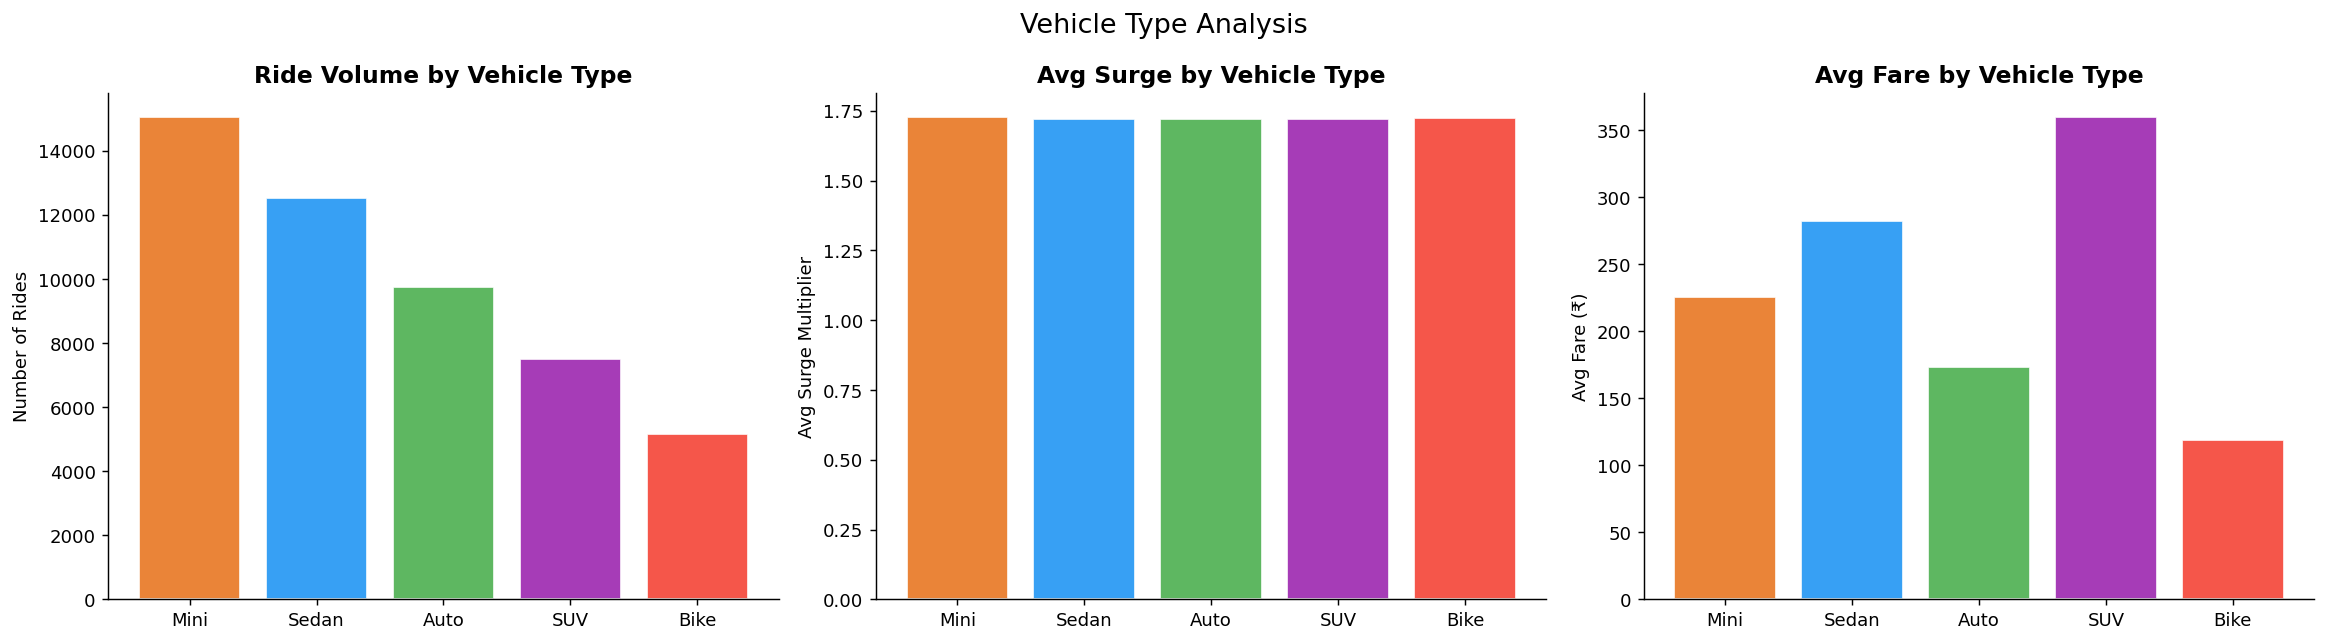

vehicle_type  avg_surge  ride_count  avg_fare  avg_dist
        Mini       1.73       15045    225.82      5.70
       Sedan       1.72       12545    282.50      5.74
        Auto       1.72        9761    173.23      5.67
         SUV       1.72        7492    359.40      5.71
        Bike       1.73        5157    118.56      5.67


In [10]:
vehicle_stats = rides_df.groupby("vehicle_type").agg(
    avg_surge  = ("surge_multiplier", "mean"),
    ride_count = ("ride_id", "count"),
    avg_fare   = ("fare_amount", "mean"),
    avg_dist   = ("distance_km", "mean")
).reset_index().sort_values("ride_count", ascending=False)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Vehicle Type Analysis", fontsize=15)

colors = ["#E87722", "#2196F3", "#4CAF50", "#9C27B0", "#F44336"]

axes[0].bar(vehicle_stats["vehicle_type"], vehicle_stats["ride_count"],
            color=colors, edgecolor="white", alpha=0.9)
axes[0].set_title("Ride Volume by Vehicle Type")
axes[0].set_ylabel("Number of Rides")

axes[1].bar(vehicle_stats["vehicle_type"], vehicle_stats["avg_surge"],
            color=colors, edgecolor="white", alpha=0.9)
axes[1].set_title("Avg Surge by Vehicle Type")
axes[1].set_ylabel("Avg Surge Multiplier")

axes[2].bar(vehicle_stats["vehicle_type"], vehicle_stats["avg_fare"],
            color=colors, edgecolor="white", alpha=0.9)
axes[2].set_title("Avg Fare by Vehicle Type")
axes[2].set_ylabel("Avg Fare (₹)")

plt.tight_layout()
plt.savefig("../data/processed/eda_08_vehicle_analysis.png", dpi=150, bbox_inches="tight")
plt.show()

print(vehicle_stats.to_string(index=False))

## Section 5 — Correlation Analysis
### Question: Which numerical features are most correlated with surge?
Correlation tells us the linear relationship between two variables.
Values close to 1 or -1 mean strong relationship.
Values close to 0 mean weak or no linear relationship.

In [13]:
# Check what columns we actually have
print(rides_df.columns.tolist())

['ride_id', 'driver_id', 'user_id', 'pickup_zone', 'drop_zone', 'pickup_lat', 'pickup_lon', 'drop_lat', 'drop_lon', 'vehicle_type', 'ride_timestamp', 'hour', 'month', 'day_of_week', 'is_weekend', 'is_holiday', 'weather_condition', 'distance_km', 'duration_min', 'base_fare', 'fare_amount', 'surge_multiplier', 'ride_status', 'cancellation_reason', 'driver_rating_given']


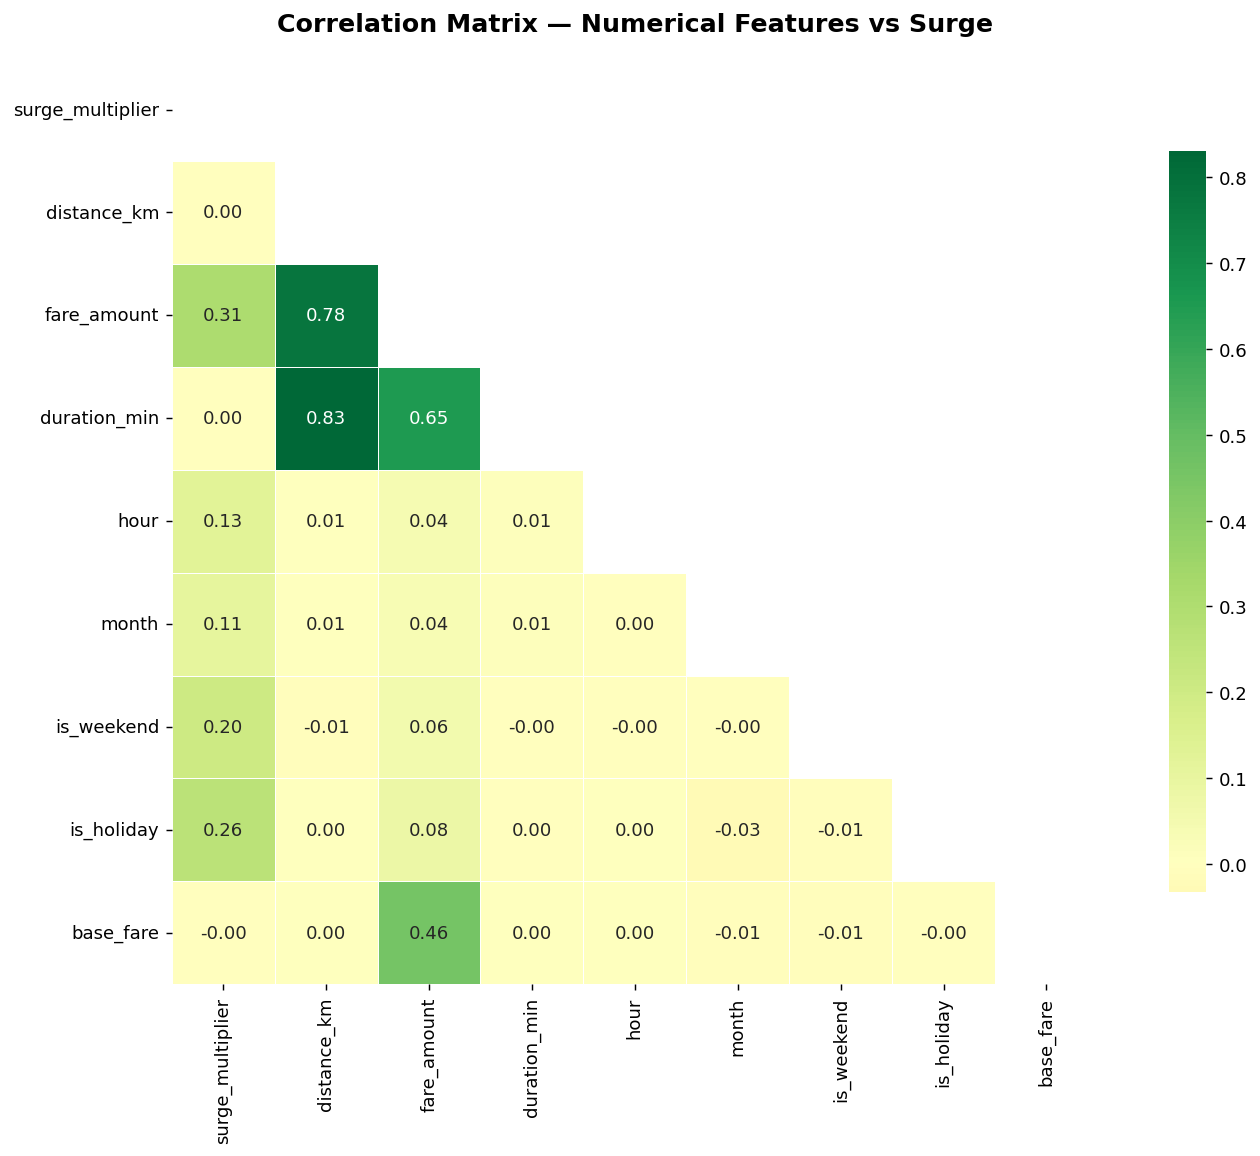

Correlation with surge_multiplier (sorted):
fare_amount     0.31
is_holiday      0.26
is_weekend      0.20
hour            0.13
month           0.11
distance_km     0.00
duration_min    0.00
base_fare      -0.00
Name: surge_multiplier, dtype: float64


In [14]:
corr_cols = [
    "surge_multiplier", "distance_km", "fare_amount",
    "duration_min", "hour", "month", "is_weekend", "is_holiday",
    "base_fare"
]

# Keep only columns that actually exist
corr_cols = [c for c in corr_cols if c in rides_df.columns]

corr_df = rides_df[corr_cols].copy()
corr_df["is_weekend"] = corr_df["is_weekend"].astype(int)
corr_df["is_holiday"] = corr_df["is_holiday"].astype(int)

corr_matrix = corr_df.corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt=".2f",
    cmap="RdYlGn",
    center=0,
    square=True,
    linewidths=0.5,
    ax=ax,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Matrix — Numerical Features vs Surge", fontsize=14, pad=15)
plt.tight_layout()
plt.savefig("../data/processed/eda_09_correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

print("Correlation with surge_multiplier (sorted):")
print(corr_matrix["surge_multiplier"].drop("surge_multiplier").sort_values(ascending=False).round(3))

## EDA Summary — Key Findings for Modeling

Fill this in after running all cells above. Template:

### Feature Importance Signals Found
| Feature | Relationship with Surge | Strength |
|---|---|---|
| hour | Double peak at 8-10am and 5-8pm | Strong |
| weather_condition | Storm and heavy rain increase surge | Strong |
| is_holiday | Holidays show significantly higher surge | Moderate |
| is_weekend | Slight increase on weekends | Moderate |
| pickup_zone | Tech corridors (Whitefield, EC) surge more | Moderate |
| month | Monsoon months show elevated surge | Moderate |
| vehicle_type | SUV/Sedan show slightly higher surge | Weak |

### What to Encode in Feature Engineering (Next Notebook)
- hour → cyclical encoding (sine/cosine) because 23 and 0 are close
- weather_condition → ordinal encoding (Clear=0 to Storm=5)
- pickup_zone → target encoding (encode by avg surge of zone)
- day_of_week → one hot encoding

### What This Means for Model Selection
- Non-linear patterns visible (hour has U-shape, not linear)
- This suggests tree-based models (XGBoost, LightGBM) will
  outperform linear models
- We will verify this in notebook 05 model training